In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv("/content/Car Market Trends Analysis with Car Dekho Data.csv")

In [55]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [56]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [58]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [59]:
print(df['Car_Name'].value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


In [60]:
df['Car_Name'] = df['Car_Name'].str.title()
display(df['Car_Name'].value_counts())


,count
Car_Name,
City,26
Corolla Altis,16
Verna,14
Fortuner,11
Brio,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [61]:
numerical_cols = df.select_dtypes(include=np.number).columns


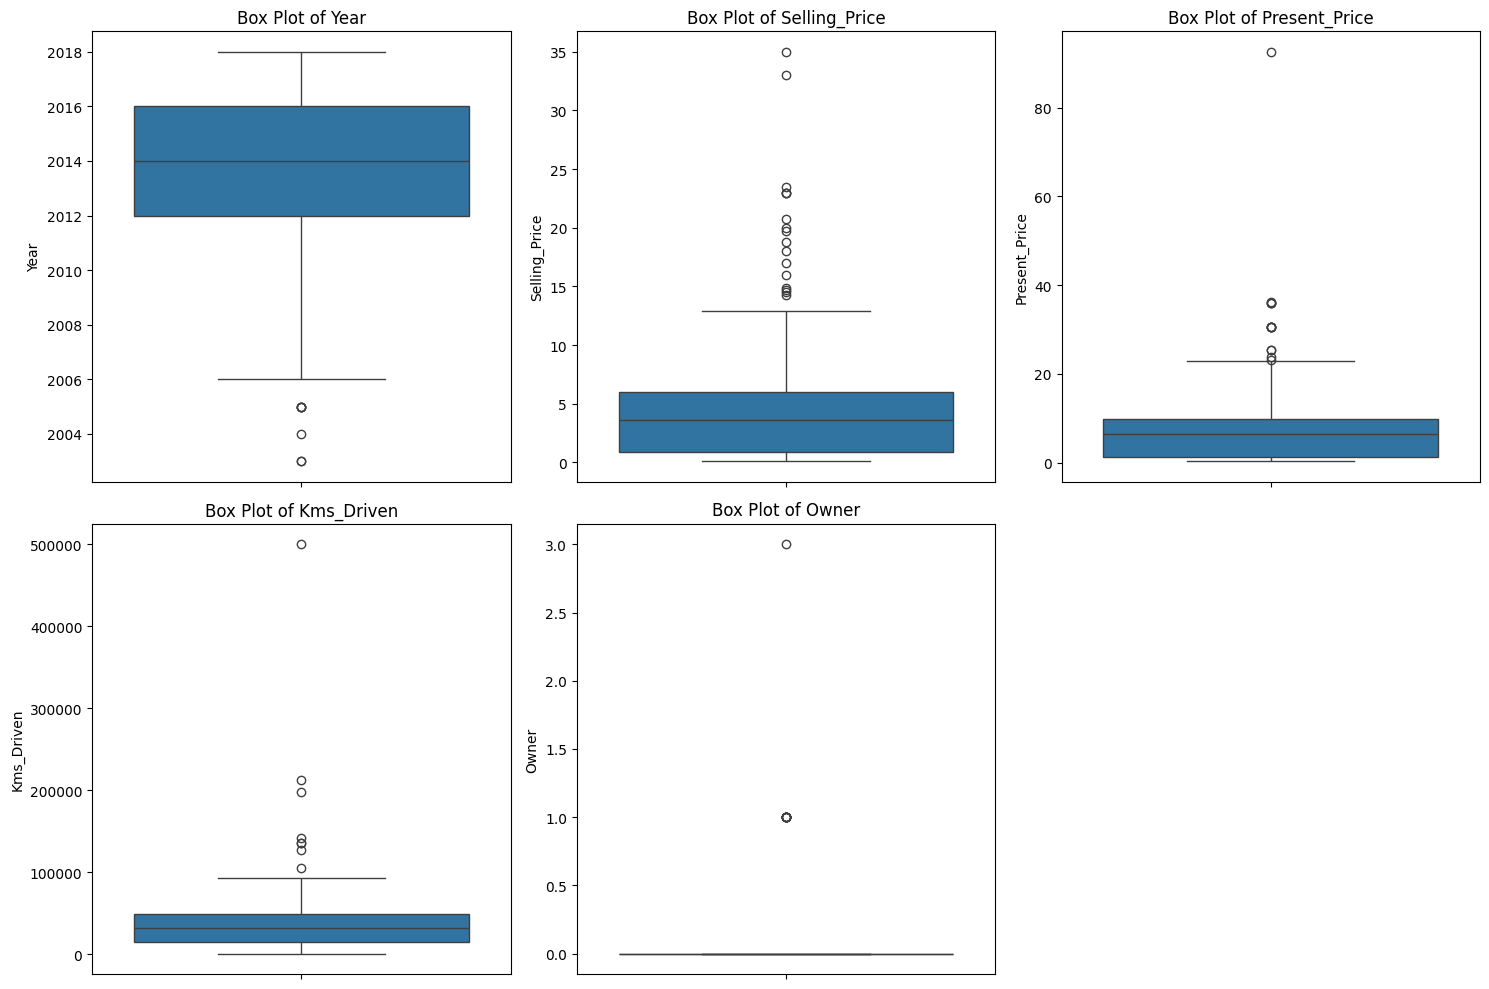

In [62]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [63]:
def remove_outlier(col_name):
    sorted(col_name)
    Q1,Q3 = col_name.quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound


In [64]:
low, high = remove_outlier(df['Year'])
df['Year'] = np.where(df['Year']>high,high,df['Year'])
df['Year'] = np.where(df['Year']<low,low,df['Year'])

low, high = remove_outlier(df['Selling_Price'])
df['Selling_Price'] = np.where(df['Selling_Price']>high,high,df['Selling_Price'])
df['Selling_Price'] = np.where(df['Selling_Price']<low,low,df['Selling_Price'])

low, high = remove_outlier(df['Present_Price'])
df['Present_Price'] = np.where(df['Present_Price']>high,high,df['Present_Price'])
df['Present_Price'] = np.where(df['Present_Price']<low,low,df['Present_Price'])

low, high = remove_outlier(df['Kms_Driven'])
df['Kms_Driven'] = np.where(df['Kms_Driven']>high,high,df['Kms_Driven'])
df['Kms_Driven'] = np.where(df['Kms_Driven']<low,low,df['Kms_Driven'])




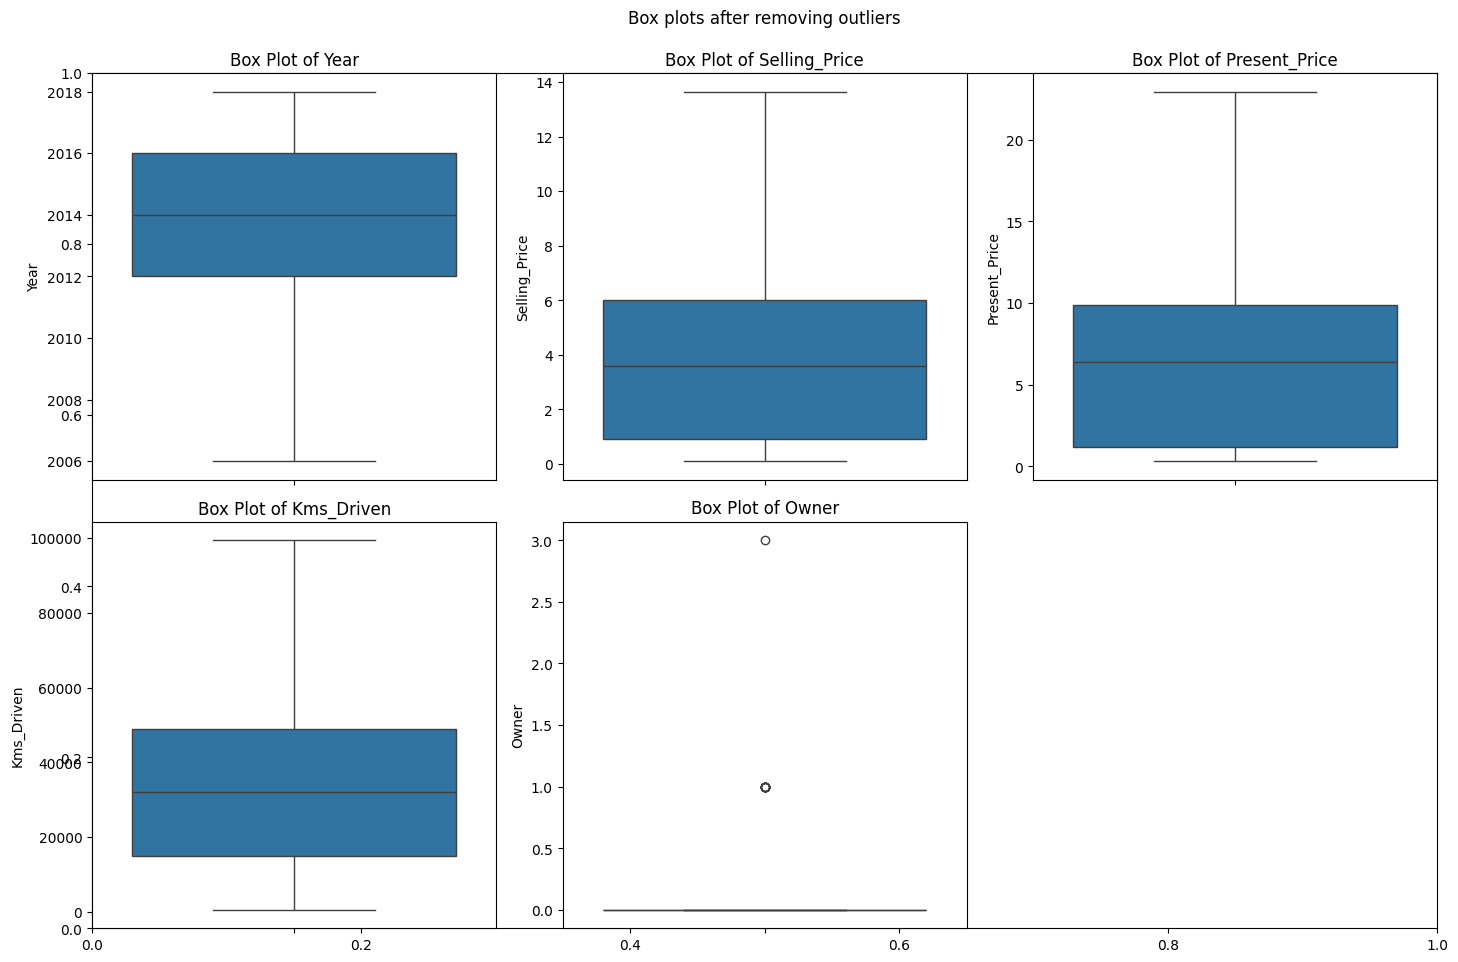

In [71]:
plt.figure(figsize=(15, 10))
plt.title('Box plots after removing outliers\n\n')
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

 1. From which manufacturing year to which manufacturing year vehicles are present in this data.

Vehicles are present from the manufacturing year 2013 to 2018

 2. What is the lowest price to which a vehicle is sold?

 The lowest price to which a vehicle is sold is 100000


3. What is the highest price to which a vehicle is sold?

The highest price to which a vehicle is sold is 35 lakhs

 4. How many records are there in this data?



In [72]:
df.shape

(301, 9)

 There are 301 records in this data

5. Are there any missing records in this data?



In [73]:
 df.isnull().sum()


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


There is no missing records in thid data

6. How many different vehicles are present in this data?

In [74]:
df['Car_Name'].nunique()

98

There are 98 different vehicles present in this data

7 . Which is the most sold vehicle in this data?

In [75]:
 df['Car_Name'].mode()[0]

'City'

The most sold vehicle in this data is city.

8. Does the database include any CNG vehicle? If yes how many of them are there?

In [76]:
print((df['Fuel_Type'] == 'CNG').sum())

2


Yes, the database includes CNG vehicles. There are 2 of them.

9. How many vehicles here are for sell from individual directly?

In [23]:
print((df['Seller_Type'] == 'Individual').sum())

106


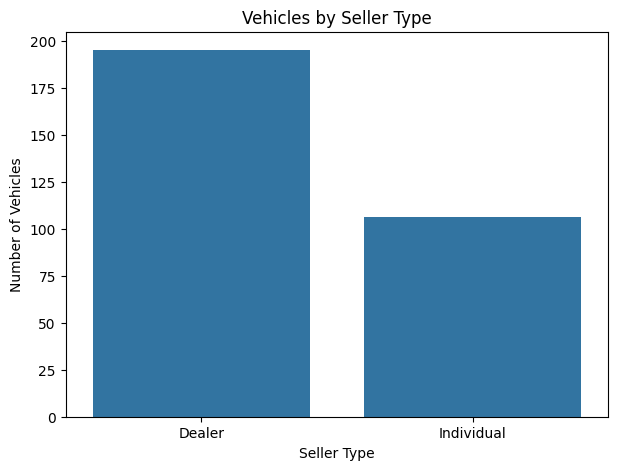

In [95]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Seller_Type')

plt.title('Vehicles by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Vehicles')
plt.show()

There are 106 vehicles for sale from individuals directly.

10. Does the database contain auto transmission vehicle? If yes how many of them are there?

In [24]:
print((df['Transmission'] == 'Automatic').sum())

40


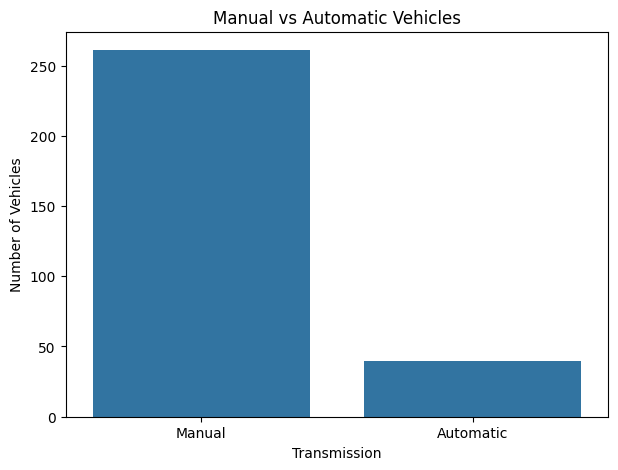

In [94]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Transmission')

plt.title('Manual vs Automatic Vehicles')
plt.xlabel('Transmission')
plt.ylabel('Number of Vehicles')
plt.show()

Yes,the database contains auto transmission vehicles. There are 40 of them.

11. How many single person owned vehicles are there in this database?

In [25]:
print((df['Owner'] == 1).sum())

10


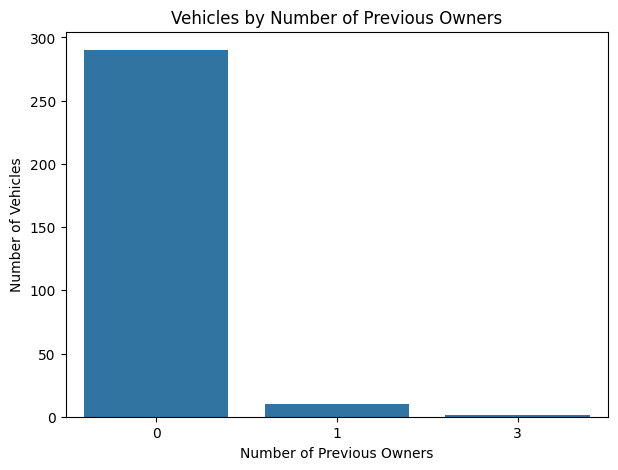

In [96]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Owner')

plt.title('Vehicles by Number of Previous Owners')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Number of Vehicles')
plt.show()

There are 10 vehicles with a single owner (Owner = 1) in this database

12. Which is the most and least cost depreciation vehicle in data?

In [77]:

df['Depreciation'] = df['Present_Price'] - df['Selling_Price']

# Most depreciated vehicle
most_depreciated = df.loc[df['Depreciation'].idxmax()]
print(f"The most depreciated vehicle is: {most_depreciated['Car_Name']} (Depreciation: {most_depreciated['Depreciation']:.2f} lakhs)")

# Least depreciated vehicle
least_depreciated = df.loc[df['Depreciation'].idxmin()]
print(f"The least depreciated vehicle is: {least_depreciated['Car_Name']} (Depreciation: {least_depreciated['Depreciation']:.2f} lakhs)")

The most depreciated vehicle is: Camry (Depreciation: 20.45 lakhs)
The least depreciated vehicle is: Honda Activa 4G (Depreciation: 0.03 lakhs)


13. Which brands of vehilces are less affected ay cost depreciation ?

In [81]:


df['Depreciation_Percentage'] = (
    df['Depreciation'] / df['Present_Price']
) * 100

brand_depreciation = df.groupby('Car_Name')['Depreciation_Percentage'].mean()
print(brand_depreciation.sort_values().head(10))

Car_Name
Vitara Brezza                5.900305
Bajaj Avenger 150            6.250000
Um Renegade Mojave           6.593407
Tvs Sport                    7.692308
Yamaha Fz 16                 8.536585
Honda Activa 4G              8.823529
Hero Passion X Pro           9.090909
Bajaj Dominar 400            9.375000
Royal Enfield Bullet 350    10.256410
Honda Dream Yuga            11.111111
Name: Depreciation_Percentage, dtype: float64


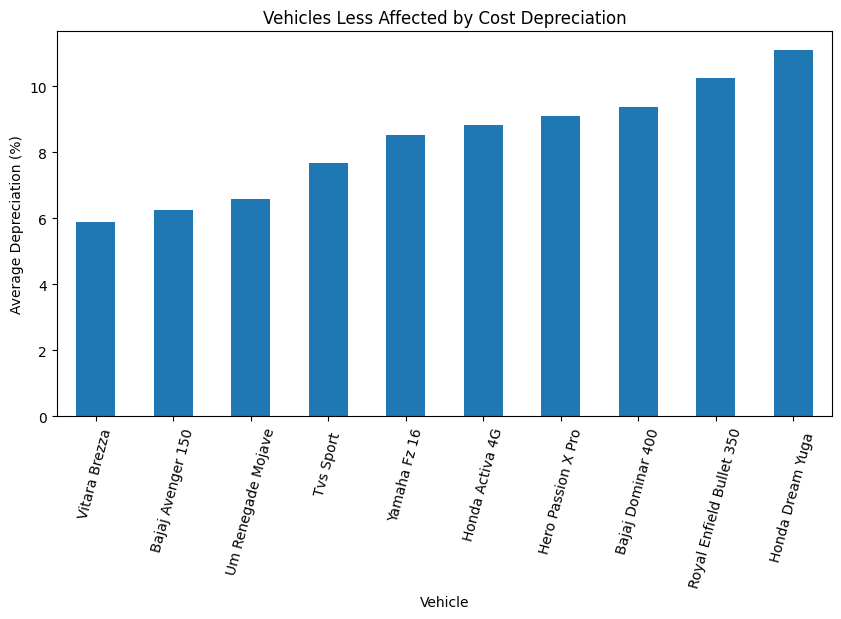

In [82]:
top_low_depreciation = brand_depreciation.sort_values().head(10)

top_low_depreciation.plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel('Vehicle')
plt.ylabel('Average Depreciation (%)')
plt.title('Vehicles Less Affected by Cost Depreciation')
plt.xticks(rotation=75)
plt.show()

14. Are there any factors which you feel affect the cost depreciation?

In [40]:
correlation = df[
    ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
     'Depreciation']
].corr()

print(correlation)

                   Year  Selling_Price  Present_Price  Kms_Driven  \
Year           1.000000       0.236141      -0.047584   -0.524342   
Selling_Price  0.236141       1.000000       0.878983    0.029187   
Present_Price -0.047584       0.878983       1.000000    0.203647   
Kms_Driven    -0.524342       0.029187       0.203647    1.000000   
Depreciation  -0.333746       0.520881       0.864902    0.333832   

               Depreciation  
Year              -0.333746  
Selling_Price      0.520881  
Present_Price      0.864902  
Kms_Driven         0.333832  
Depreciation       1.000000  


15. In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data?

Correlation between Selling Price and Age: -0.28
Correlation between Selling Price and Kms Driven: 0.13


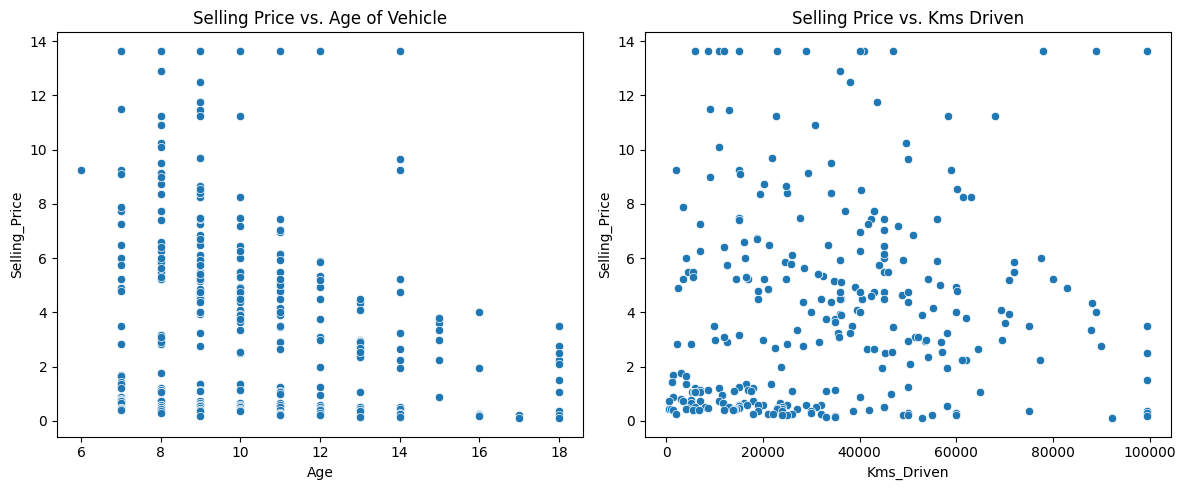

In [83]:

current_year = 2024
df['Age'] = current_year - df['Year']


correlation_age = df['Selling_Price'].corr(df['Age'])
correlation_kms = df['Selling_Price'].corr(df['Kms_Driven'])

print(f"Correlation between Selling Price and Age: {correlation_age:.2f}")
print(f"Correlation between Selling Price and Kms Driven: {correlation_kms:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Age', y='Selling_Price')
plt.title('Selling Price vs. Age of Vehicle')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price')
plt.title('Selling Price vs. Kms Driven')

plt.tight_layout()
plt.show()

As the age increases the selling price decreases

16. Can we get idea about newest vehicles i.e, after 2014 manufactured ?

In [26]:
print((df['Year'] > 2014).sum())

147


There are about 147 newest vehicles after 2014 manufacture.

17. Can we find out data of only two wheelers from this data ?

18. Which is the oldest bike sold here?

19. Whlch Is the newest bike sold here?

20. Which is the most sold bike here?

21. Do you find any deal in two wheelers which exceeded the general expectation ? can you find reason for it?

22. can we find out data of only cars from this data

23. Which is the oldest car sold here?

In [79]:
oldest_car = df[df['Year'] == df['Year'].min()]

print(oldest_car[
    ['Car_Name', 'Year', 'Selling_Price',
     'Present_Price', 'Kms_Driven']
])

                Car_Name    Year  Selling_Price  Present_Price  Kms_Driven
37                   800  2006.0           0.35           2.28     99417.5
39                   Sx4  2006.0           2.25           7.98     62000.0
47               Wagon R  2006.0           1.05           4.15     65000.0
54                Innova  2006.0           2.75          10.21     90000.0
77               Corolla  2006.0           1.50          12.35     99417.5
84                Innova  2006.0           3.49          13.46     99417.5
85                 Camry  2006.0           2.50          22.95     99417.5
92                Innova  2006.0           3.51          13.70     75000.0
189  Hero Super Splendor  2006.0           0.20           0.57     55000.0
200     Bajaj Pulsar 150  2006.0           0.10           0.75     92233.0
281                 City  2006.0           2.10           7.60     50456.0


24. Which is the newest car sold here?

In [80]:
newest_car = df[df['Year'] == df['Year'].max()]

print(newest_car[
    ['Car_Name', 'Year', 'Selling_Price',
     'Present_Price', 'Kms_Driven']
])

        Car_Name    Year  Selling_Price  Present_Price  Kms_Driven
5  Vitara Brezza  2018.0           9.25           9.83      2071.0


25. Do you find any deal in cars which exceeded the general expectation? Can you find reason for it?

In [46]:
df['Depreciation'] = (
    df['Present_Price'] - df['Selling_Price']
)

df['Depreciation_Percentage'] = (
    df['Depreciation'] /
    df['Present_Price']
) * 100

best_car_deal = df.loc[
    df['Depreciation_Percentage'].idxmin()
]

print(best_car_deal)

Car_Name                   corolla altis
Year                                2016
Selling_Price                      14.73
Present_Price                      14.89
Kms_Driven                         23000
Fuel_Type                         Diesel
Seller_Type                       Dealer
Transmission                      Manual
Owner                                  0
Depreciation                        0.16
Age                                    8
Car_Name_Clean             corolla altis
Depreciation_Percentage         1.074547
Name: 80, dtype: object


 Distribution of Vehicle Manufacturing Years and Kilometers Driven


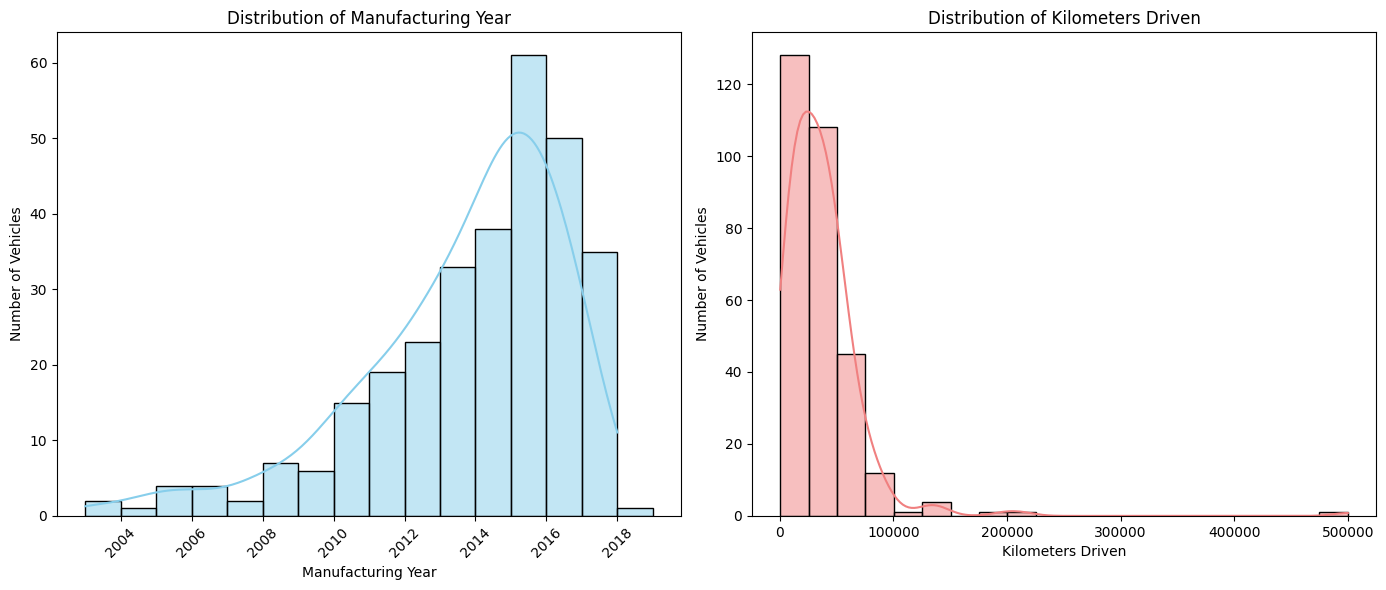

In [51]:
plt.figure(figsize=(14, 6))

# Histogram for Year
plt.subplot(1, 2, 1)
sns.histplot(df['Year'], bins=range(df['Year'].min(), df['Year'].max() + 2), kde=True, color='skyblue')
plt.title('Distribution of Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)

# Histogram for Kms_Driven
plt.subplot(1, 2, 2)
sns.histplot(df['Kms_Driven'], bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Number of Vehicles')

plt.tight_layout()
plt.show()

The manufacturing year histogram shows a higher concentration of newer vehicles (post-2010), especially around 2014-2016. The kilometers driven histogram indicates that most vehicles have relatively low mileage, with a long tail extending to very high mileage vehicles.

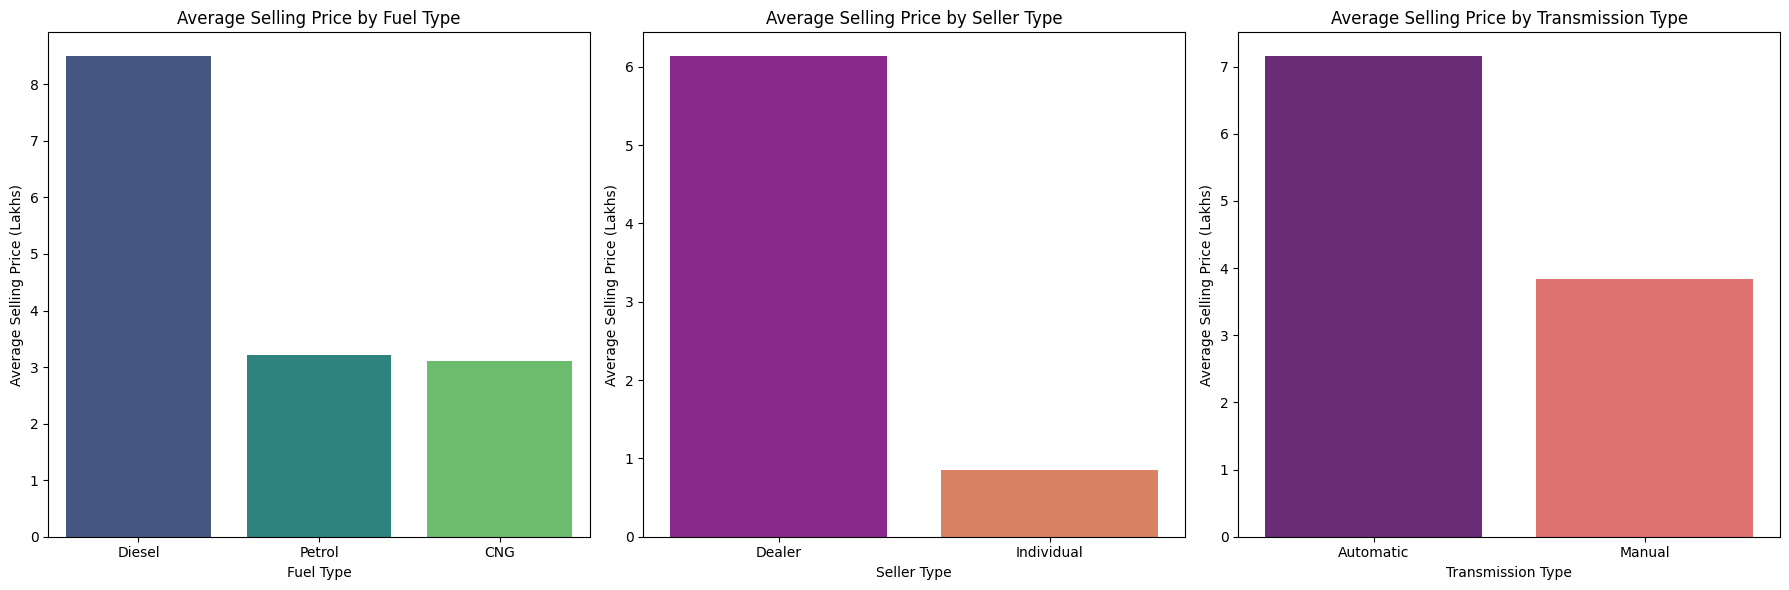

In [87]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
fuel_avg_price = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
sns.barplot(x=fuel_avg_price.index, y=fuel_avg_price.values, hue=fuel_avg_price.index, palette='viridis', legend=False)
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (Lakhs)')


plt.subplot(1, 3, 2)
seller_avg_price = df.groupby('Seller_Type')['Selling_Price'].mean().sort_values(ascending=False)
sns.barplot(x=seller_avg_price.index, y=seller_avg_price.values, hue=seller_avg_price.index, palette='plasma', legend=False)
plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price (Lakhs)')


plt.subplot(1, 3, 3)
transmission_avg_price = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
sns.barplot(x=transmission_avg_price.index, y=transmission_avg_price.values, hue=transmission_avg_price.index, palette='magma', legend=False)
plt.title('Average Selling Price by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Average Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

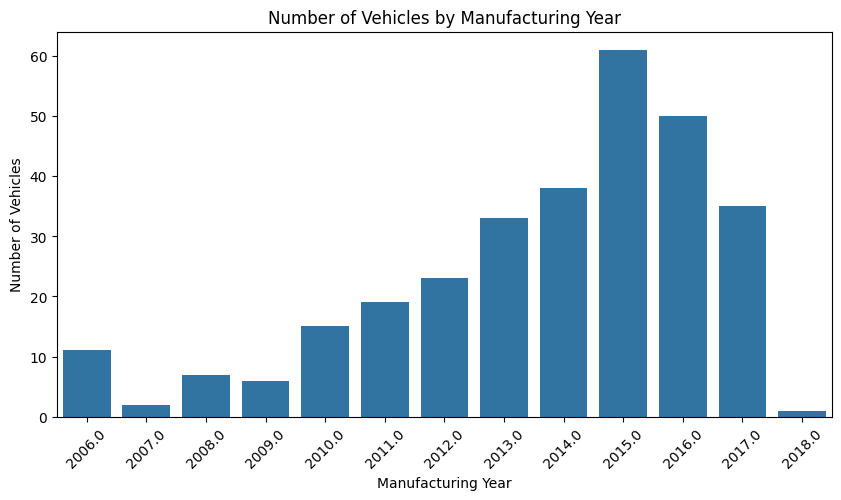

In [89]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='Year')

plt.title('Number of Vehicles by Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.show()

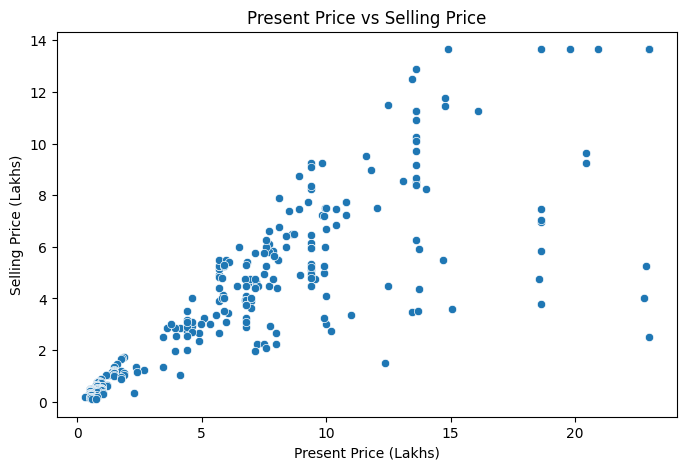

In [92]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Present_Price',
    y='Selling_Price'
)

plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

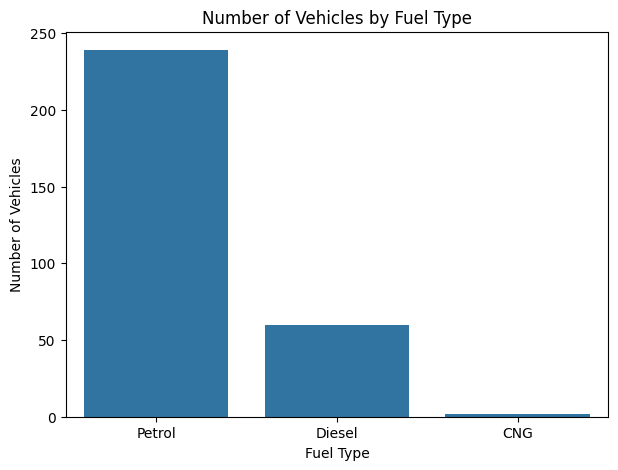

In [93]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Fuel_Type')

plt.title('Number of Vehicles by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Vehicles')
plt.show()